In [2]:
import pandas as pd

df = pd.read_csv(r"C:\SkillCraft_DataScience\SCT_DS_2\data\netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


np.int64(0)

In [4]:
df = df.drop_duplicates()
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")


In [5]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


In [6]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [7]:

df['duration_value'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract('([a-zA-Z]+)')

In [8]:
df.isnull().sum()
df.duplicated().sum()
df.info()
df[['duration', 'duration_value', 'duration_unit']].head(10)
len(df)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         8807 non-null   object        
 1   type            8807 non-null   object        
 2   title           8807 non-null   object        
 3   director        8807 non-null   object        
 4   cast            8807 non-null   object        
 5   country         8807 non-null   object        
 6   date_added      8709 non-null   datetime64[ns]
 7   release_year    8807 non-null   int64         
 8   rating          8803 non-null   object        
 9   duration        8804 non-null   object        
 10  listed_in       8807 non-null   object        
 11  description     8807 non-null   object        
 12  year_added      8709 non-null   float64       
 13  month_added     8709 non-null   float64       
 14  duration_value  8804 non-null   float64       
 15  dura

8807

In [9]:
df['type'].unique()
df['rating'].unique()
df['duration_unit'].unique()


array(['min', 'Seasons', 'Season', nan], dtype=object)

<Axes: xlabel='type'>

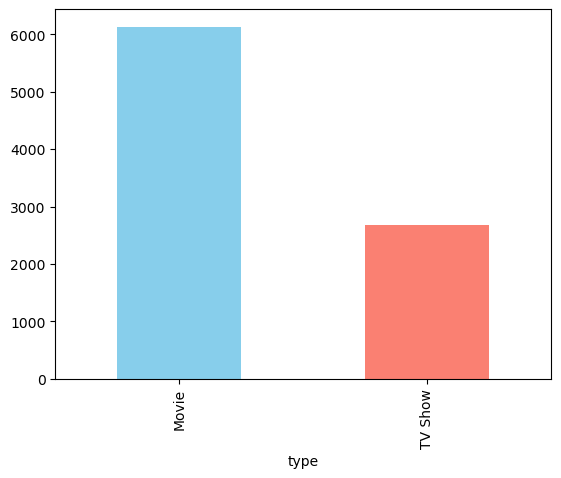

In [10]:
df['type'].value_counts().plot(kind='bar', color=['skyblue','salmon'])


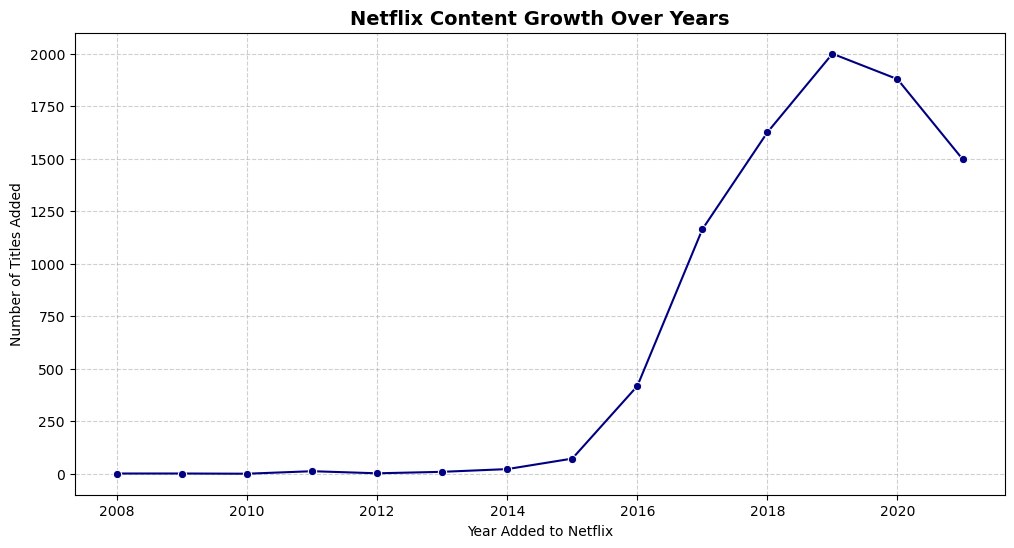

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

content_by_year = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=content_by_year.index, y=content_by_year.values, marker="o", color="navy")
plt.title("Netflix Content Growth Over Years", fontsize=14, fontweight="bold")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Number of Titles Added")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


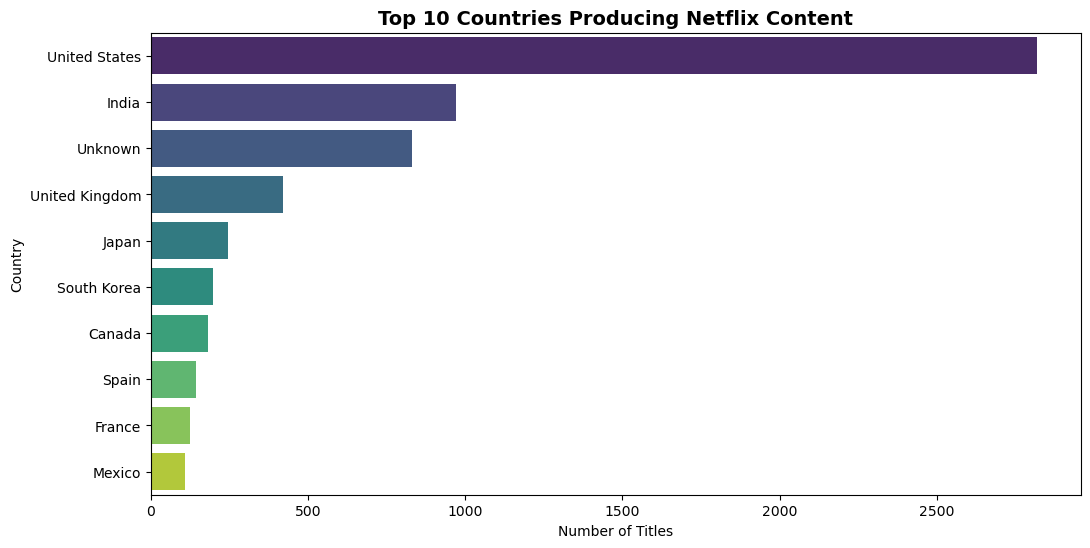

In [13]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,   # fixes the palette warning
    palette="viridis",
    dodge=False,
    legend=False
)
plt.title("Top 10 Countries Producing Netflix Content", fontsize=14, fontweight="bold")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

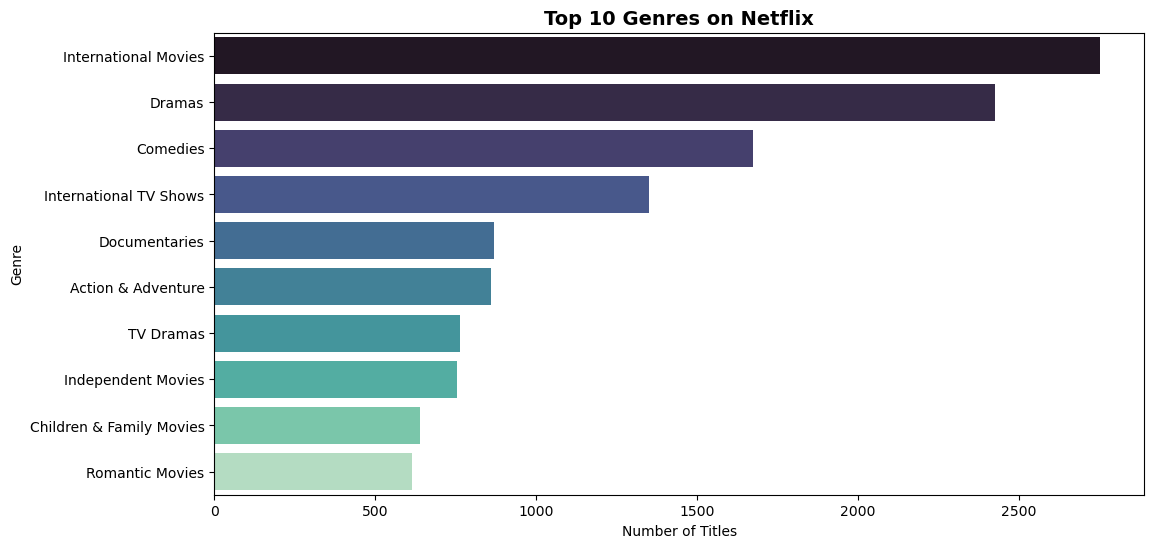

In [15]:
all_genres = df['listed_in'].str.split(',').explode().str.strip()

# Count top 10 genres
top_genres = all_genres.value_counts().head(10)

# Plot (future-proof)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,   # explicitly set hue
    palette="mako",
    dodge=False,
    legend=False
)
plt.title("Top 10 Genres on Netflix", fontsize=14, fontweight="bold")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()


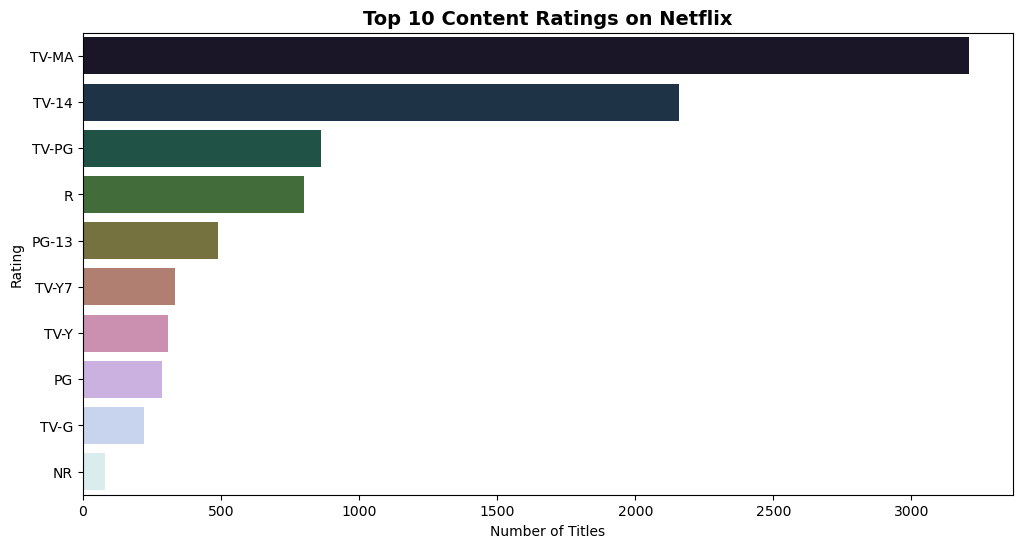

In [16]:
rating_counts = df['rating'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index,
    hue=rating_counts.index,   # explicitly set hue
    palette="cubehelix",
    dodge=False,
    legend=False
)
plt.title("Top 10 Content Ratings on Netflix", fontsize=14, fontweight="bold")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.show()
